In [13]:
import numpy as np
from math import ceil
from scipy import stats
from scipy.integrate import quad
import pandas as pd 

limit = 1000000

primes_long = pd.read_csv("/Users/admin/Downloads/numbers.csv")
primes_long["value"] = pd.to_numeric(primes_long["value"]).astype(int)
primes = primes_long[primes_long["value"] < limit]['value'].tolist()

def find_circular_primes(primes):
    prime_set = set(primes)
    def is_circular(p):
        s = str(p)
        rotations = [int(s[i:] + s[:i]) for i in range(len(s))]
        return all(r in prime_set for r in rotations)
    return [p for p in primes if is_circular(p)]

def calculate_bin_size(circular_starts):
    min_counts_per_bin = 5
    sorted_circular = sorted(circular_starts)
    bin_size = 0
    for i in range(len(sorted_circular) - min_counts_per_bin):
        current_gap = sorted_circular[i + min_counts_per_bin] - sorted_circular[i]
        if current_gap > bin_size:
            bin_size = current_gap
    return ceil(bin_size)

def count_primes_in_bins(circular_starts, num_bins, bin_size):
    bin_labels = []
    prime_counts = []
    circular_counts = []
    for i in range(num_bins):
        lo = 2 if i == 0 else i * bin_size
        hi = (i + 1) * bin_size
        bin_labels.append(f"{lo}-{hi}")
        prime_counts.append(sum(1 for p in primes if lo <= p <= hi))
        circular_counts.append(sum(1 for p in circular_starts if lo <= p <= hi))
    return bin_labels, prime_counts, circular_counts

def hardy_littlewood_conjecture(num_bins, bin_size):
    C2 = 0.6601618158
    expected_values = []
    def integrand(t):
        return 1 / (np.log(t) ** 2)
    for i in range(num_bins):
        lo = 2 if i == 0 else i * bin_size
        hi = (i + 1) * bin_size
        area, _ = quad(integrand, lo, hi)
        expected_values.append(2 * C2 * area)
    return expected_values

def chi_square_goodness_of_fit(observed_values, expected_values):
    statistic = 0
    significance_level = 0.05
    for i in range(len(observed_values)):
        if expected_values[i] > 0:
            statistic += np.square(observed_values[i] - expected_values[i]) / expected_values[i]
    df = len(observed_values) - 1
    p_value = stats.chi2.sf(statistic, df)
    print(f"Chi-square statistic: {statistic:.4f}, p-value: {p_value:.4f}, df: {df}")
    if p_value > significance_level:
        print("Fail to reject H0")
    else:
        print("Reject H0")

circular_starts = find_circular_primes(primes)
bin_size = calculate_bin_size(circular_starts)
num_bins = ceil(limit / bin_size)
labels, prime_counts, observed_values = count_primes_in_bins(circular_starts, num_bins, bin_size)

for i in range(num_bins):
    print(f"Bin {labels[i]}: {observed_values[i]} circular primes")

expected_values = hardy_littlewood_conjecture(num_bins, bin_size)

print("H0: no significant difference between the distribution of circular primes and the Hardy-Littlewood Conjecture")
print("H1: significant difference exists")
chi_square_goodness_of_fit(observed_values, expected_values)

Bin 2-719460: 49 circular primes
Bin 719460-1438920: 6 circular primes
H0: no significant difference between the distribution of circular primes and the Hardy-Littlewood Conjecture
H1: significant difference exists
Chi-square statistic: 11092.0592, p-value: 0.0000, df: 1
Reject H0


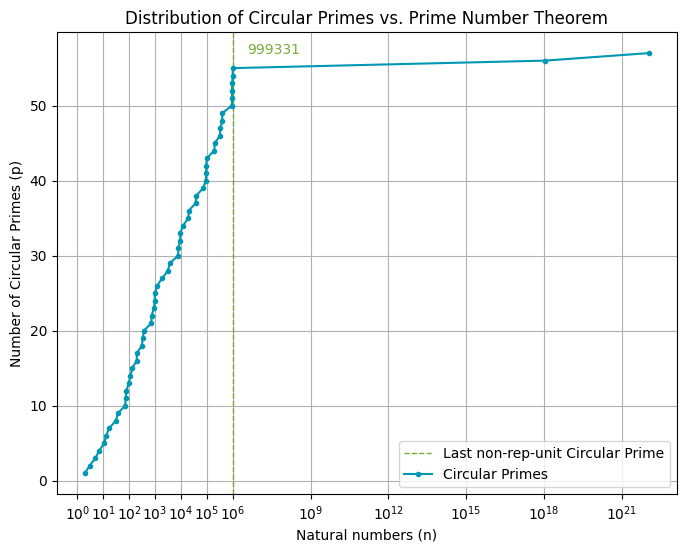

In [36]:
# Circular Prime Visualization
import numpy as np
import matplotlib.pyplot as plt


xp = [2, 3, 5, 7, 11, 13, 17, 31, 37, 71, 73, 79, 97, 113, 131, 197, 199, 311, 337, 373, 719, 733, 919, 971, 991, 1193, 1931, 3119, 3779, 7793, 7937, 9311, 9377, 11939, 19391, 19937, 37199, 39119, 71993, 91193, 93719, 93911, 99371, 193939, 199933, 319993, 331999, 391939, 393919, 919393, 933199, 939193, 939391, 993319, 999331, 1111111111111111111, 11111111111111111111111]
yp= range(1, len(xp)+1)
# The circular prime list supplemented with R19 and R23 and the number of primes list (just the length of xp)
plt.figure(figsize=(8,6))
plt.xscale('log')
plt.title('Distribution of Circular Primes vs. Prime Number Theorem')
plt.xticks([1e0,1e1,1e2,1e3,1e4,1e5,1e6,1e9,1e12,1e15,1e18,1e21])
plt.xlabel('Natural numbers (n)')
plt.ylabel('Number of Circular Primes (p)')
plt.axvline(x=999331, color='#78ab37', linestyle='--', linewidth=1, label='Last non-rep-unit Circular Prime')
plt.plot(xp,yp, marker='.', label='Circular Primes', color='#0097b2')
plt.legend()
plt.grid('0')
plt.annotate("999331",(xp[54], yp[54]), xytext=(10, 10), textcoords='offset points', color='#78ab37')
# Scaling customizing and adding extra information
plt.show()